In [18]:
import heapq
import numpy as np
import matplotlib.pyplot as plt

def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])  # Manhattan

def reconstruct_path(came_from, current):
    path = [current]
    while current in came_from:
        current = came_from[current]
        path.append(current)
    path.reverse()
    return path

def getNeighbors(r, c, maze):
    rows, cols = maze.shape
    neighbors = []

    for rr, cc in [(r-1,c), (r+1,c), (r,c-1), (r,c+1)]:  # upp, ner, vänster, höger
        if 0 <= rr < rows and 0 <= cc < cols:
            if maze[rr][cc] == 0:       # bara gångar
                neighbors.append((rr, cc))  # tuple
    return neighbors

# In DFS: Stack, BFS: Queue, A*: Priority Queue
def Astar(maze, startNode, endNode):
    startNode = tuple(startNode)        # säkerställ tuple
    endNode = tuple(endNode)

    frontier = []                       # priority queue
    heapq.heappush(frontier, (0, startNode))

    explored = []                       # för plotting
    came_from = {}                      # för path
    g_score = {startNode: 0}            # kostnad hittills
    in_frontier = {startNode}

    while frontier:
        _, currentNode = heapq.heappop(frontier)
        in_frontier.discard(currentNode)

        if currentNode in explored:
            continue

        explored.append(currentNode)

        if currentNode == endNode:
            path = reconstruct_path(came_from, currentNode)
            return "success!", explored, path

        for nb in getNeighbors(currentNode[0], currentNode[1], maze):
            tentative_g = g_score[currentNode] + 1  # stegkostnad

            if nb not in g_score or tentative_g < g_score[nb]:
                came_from[nb] = currentNode
                g_score[nb] = tentative_g
                f = tentative_g + heuristic(nb, endNode)

                if nb not in in_frontier:
                    heapq.heappush(frontier, (f, nb))
                    in_frontier.add(nb)

    return "failure", explored, []


[1, 1] [15, 15]
success!


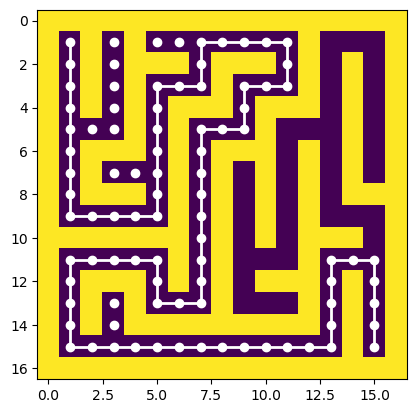

In [19]:
plt.imshow(maze)
print(startLocation, targetLocation)

answer, explored, path = Astar(maze, startLocation, targetLocation)
print(answer)

if len(explored) > 0:
    plt.plot(np.transpose(explored)[1], np.transpose(explored)[0], 'ow')

if len(path) > 0:
    plt.plot(np.transpose(path)[1], np.transpose(path)[0], '-w', linewidth=2)

plt.show()
